# Load Parsed Table

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Works when the notebook starts in the root or notebooks folder.
ROOT = Path.cwd()

if not (ROOT / "requirements.txt").exists():
    ROOT = ROOT.parent

if not (ROOT / "requirements.txt").exists():
    raise RuntimeError("Open the notebook from the project folder.")

reads = pd.read_parquet(ROOT / "data/processed/data0_reads.parquet")

SITE_KEYS = ["transcript_id", "transcript_position"]

display(reads.head())
print(f"Read rows: {len(reads):,}")

,transcript_id,transcript_position,sequence,central_5mer,n_reads,read_idx,minus1_dwell,minus1_signal_sd,minus1_signal_mean,central_dwell,central_signal_sd,central_signal_mean,plus1_dwell,plus1_signal_sd,plus1_signal_mean,gene_id,label
0,ENST00000000233,244,AAGACCA,AGACC,185,0,0.00299,2.06,125.0,0.01770,10.40,122.0,0.00930,10.90,84.1,ENSG00000004059,0
1,ENST00000000233,244,AAGACCA,AGACC,185,1,0.00631,2.53,125.0,0.00844,4.67,126.0,0.01030,6.30,80.9,ENSG00000004059,0
2,ENST00000000233,244,AAGACCA,AGACC,185,2,0.00465,3.92,109.0,0.01360,12.00,124.0,0.00498,2.13,79.6,ENSG00000004059,0
3,ENST00000000233,244,AAGACCA,AGACC,185,3,0.00398,2.06,125.0,0.00830,5.01,130.0,0.00498,3.78,80.4,ENSG00000004059,0
4,ENST00000000233,244,AAGACCA,AGACC,185,4,0.00664,2.92,120.0,0.00266,3.94,129.0,0.01300,7.15,82.2,ENSG00000004059,0


Read rows: 11,027,106


# Site Table
For EDA.

In [2]:
# Validate the repeated site metadata before creating site table
site_metadata = [
    "sequence",
    "central_5mer",
    "n_reads",
    "gene_id",
    "label",
]

metadata_counts = (
    reads.groupby(SITE_KEYS)[site_metadata]
    .nunique(dropna=False)
)

assert not metadata_counts.gt(1).any().any(), (
    "Some sites have inconsistent metadata."
)

assert not reads.duplicated(
    SITE_KEYS + ["read_idx"]
).any(), "Duplicate read keys found."

assert reads["central_5mer"].eq(
    reads["sequence"].str[1:6]
).all(), "Central 5-mer does not match the sequence."

# Check that the stored count matches the actual number of rows.
coverage_check = (
    reads.groupby(SITE_KEYS)
    .agg(
        observed_reads=("read_idx", "size"),
        stored_n_reads=("n_reads", "first"),
    )
)

assert coverage_check["observed_reads"].eq(
    coverage_check["stored_n_reads"]
).all(), "Stored n_reads does not match the parsed rows."

print("Site metadata and read counts are consistent.")

Site metadata and read counts are consistent.


In [3]:
# One row per site for site-level counts.
sites = (
    reads[SITE_KEYS + site_metadata]
    .drop_duplicates(subset=SITE_KEYS)
    .reset_index(drop=True)
    .copy()
)

# All sites for coverage and data-quality analysis are kept.
# Only labelled records for label comparisons are used.
labelled_sites = sites.dropna(subset=["label"]).copy()
labelled_reads = reads.dropna(subset=["label"]).copy()

summary = pd.Series({
    "read_rows": len(reads),
    "sites": len(sites),
    "transcripts": sites["transcript_id"].nunique(),
    "genes_with_metadata": sites["gene_id"].nunique(),
    "sites_without_labels": sites["label"].isna().sum(),
})

display(summary)
display(sites.head())

read_rows               11027106
sites                     121838
transcripts                 5333
genes_with_metadata         3852
sites_without_labels           0
dtype: int64

,transcript_id,transcript_position,sequence,central_5mer,n_reads,gene_id,label
0,ENST00000000233,244,AAGACCA,AGACC,185,ENSG00000004059,0
1,ENST00000000233,261,CAAACTG,AAACT,172,ENSG00000004059,0
2,ENST00000000233,316,GAAACAG,AAACA,185,ENSG00000004059,0
3,ENST00000000233,332,AGAACAT,GAACA,200,ENSG00000004059,0
4,ENST00000000233,368,AGGACAA,GGACA,198,ENSG00000004059,0


# EDA

## Dataset Summary

In [4]:
summary = pd.Series({
    "site_read_observations": len(reads),
    "sites": len(sites),
    "transcripts": sites["transcript_id"].nunique(),
    "genes_with_metadata": sites["gene_id"].nunique(),
    "sites_without_labels": int(sites["label"].isna().sum()),
    "read_rows_without_labels": int(reads["label"].isna().sum()),
})

display(summary)

# Missing values in each column of the per-read table.
display(
    reads.isna().sum()
    .sort_values(ascending=False)
)

site_read_observations      11027106
sites                         121838
transcripts                     5333
genes_with_metadata             3852
sites_without_labels               0
read_rows_without_labels           0
dtype: int64

transcript_id          0
transcript_position    0
sequence               0
central_5mer           0
n_reads                0
read_idx               0
minus1_dwell           0
minus1_signal_sd       0
minus1_signal_mean     0
central_dwell          0
central_signal_sd      0
central_signal_mean    0
plus1_dwell            0
plus1_signal_sd        0
plus1_signal_mean      0
gene_id                0
label                  0
dtype: int64

## Class Imbalance
Severely imbalanced dataset.

,sites,percentage
label,,
0,116363,95.506328
1,5475,4.493672


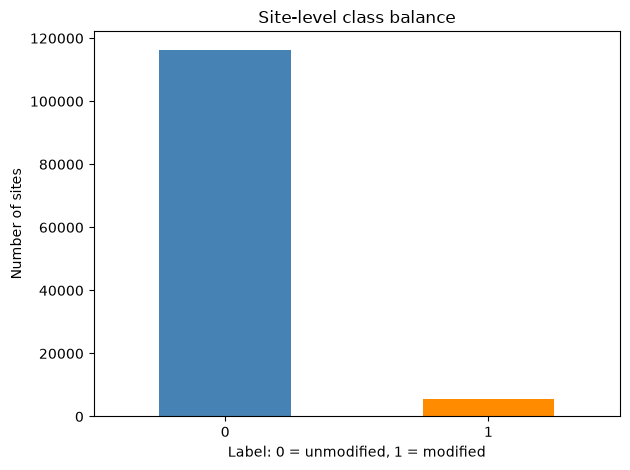

In [22]:
class_counts = (
    labelled_sites["label"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .sort_index()
)

class_summary = pd.DataFrame({
    "sites": class_counts,
    "percentage": class_counts / class_counts.sum() * 100,
})

display(class_summary)

class_counts.plot.bar(
    color=["steelblue", "darkorange"],
    rot=0,
)

plt.xlabel("Label: 0 = unmodified, 1 = modified")
plt.ylabel("Number of sites")
plt.title("Site-level class balance")
plt.tight_layout()
plt.show()

## Read coverage
Sites with few reads may have less stable summary statistics.

count    121838.000000
mean         90.506295
std         137.333376
min          20.000000
1%           20.000000
5%           22.000000
25%          32.000000
50%          47.000000
75%          84.000000
95%         304.000000
99%         869.000000
max         991.000000
Name: n_reads, dtype: float64

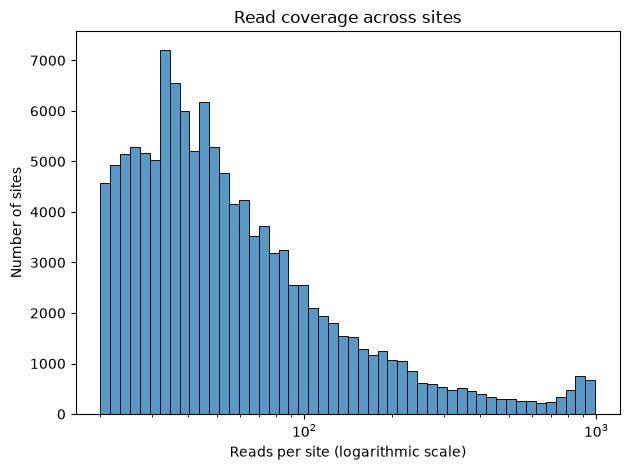

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,116363.0,90.471473,137.518566,20.0,32.0,47.0,84.0,991.0
1,5475.0,91.246393,133.346687,20.0,32.0,48.0,87.0,966.0


In [5]:
display(
    sites["n_reads"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    )
)

sns.histplot(
    data=sites,
    x="n_reads",
    bins=50,
    log_scale=True,
)

plt.xlabel("Reads per site (logarithmic scale)")
plt.ylabel("Number of sites")
plt.title("Read coverage across sites")
plt.tight_layout()
plt.show()

display(
    labelled_sites.groupby("label")["n_reads"].describe()
)

In [6]:
# Descriptive cutoffs for EDA, not filtering rules.
coverage_summary = pd.DataFrame([
    {
        "condition": f"n_reads < {cutoff}",
        "sites": int((sites["n_reads"] < cutoff).sum()),
        "percentage": 100 * (sites["n_reads"] < cutoff).mean(),
    }
    for cutoff in [5, 10, 20]
])

display(coverage_summary)

,condition,sites,percentage
0,n_reads < 5,0,0.0
1,n_reads < 10,0,0.0
2,n_reads < 20,0,0.0


## Sites per gene
These are transcript-position sites. Different transcripts from the same gene may refer to overlapping biological positions; this does not count unique genomic loci.

count    3852.000000
mean       31.629803
std        27.703695
min         1.000000
25%        14.000000
50%        25.000000
75%        41.000000
max       274.000000
Name: n_sites, dtype: float64

,n_sites
gene_id,
ENSG00000128050,274
ENSG00000110321,253
ENSG00000164924,250
ENSG00000141367,230
ENSG00000138434,229


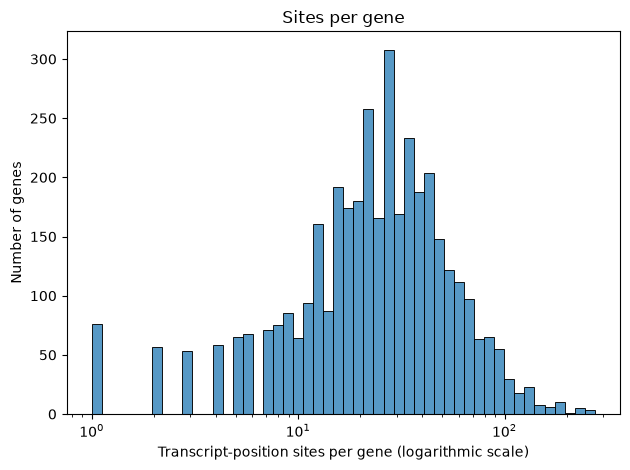

In [7]:
sites_per_gene = (
    sites.dropna(subset=["gene_id"])
    .groupby("gene_id")
    .size()
    .rename("n_sites")
    .sort_values(ascending=False)
)

display(sites_per_gene.describe())
display(sites_per_gene.head(5).to_frame())

sns.histplot(
    x=sites_per_gene,
    bins=50,
    log_scale=True,
)

plt.xlabel("Transcript-position sites per gene (logarithmic scale)")
plt.ylabel("Number of genes")
plt.title("Sites per gene")
plt.tight_layout()
plt.show()

## Full 7-mer freq by label
The plotted percentages use all sites in each class as the denominator, not just the top 20 sequences.

label,0,1
sequence,,
AAAACAA,1357,2
AGAACAA,948,6
AAAACAT,912,2
AAAACTT,886,16
AAAACTG,844,49
GAAACAG,876,6
AAAACCA,866,2
AAGACCA,829,5
AGAACAT,811,23


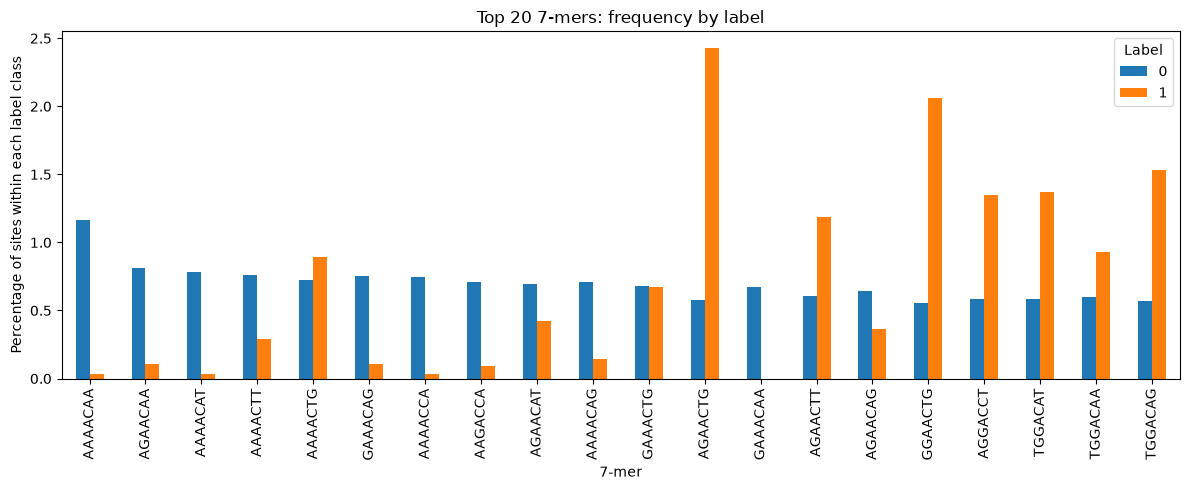

In [8]:
sequence_counts = pd.crosstab(
    labelled_sites["sequence"],
    labelled_sites["label"],
).reindex(columns=[0, 1], fill_value=0)

# Each column sums to 100% when that label class is present.
sequence_percentages = (
    sequence_counts
    .div(
        sequence_counts.sum(axis=0).replace(0, float("nan")),
        axis="columns",
    )
    * 100
)

top_sequences = (
    sequence_counts.sum(axis=1)
    .nlargest(20)
    .index
)

display(sequence_counts.loc[top_sequences])

sequence_percentages.loc[top_sequences].plot.bar(
    figsize=(12, 5),
)

plt.xlabel("7-mer")
plt.ylabel("Percentage of sites within each label class")
plt.title("Top 20 7-mers: frequency by label")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

## 5-mer freq by label

label,0,1
central_5mer,,
AAACA,10114,38
AAACT,8372,255
GAACA,7747,187
GGACA,7036,691
TGACA,7650,68
AGACA,7249,147
GGACC,6801,552
TGACC,7214,90
GAACT,6174,783


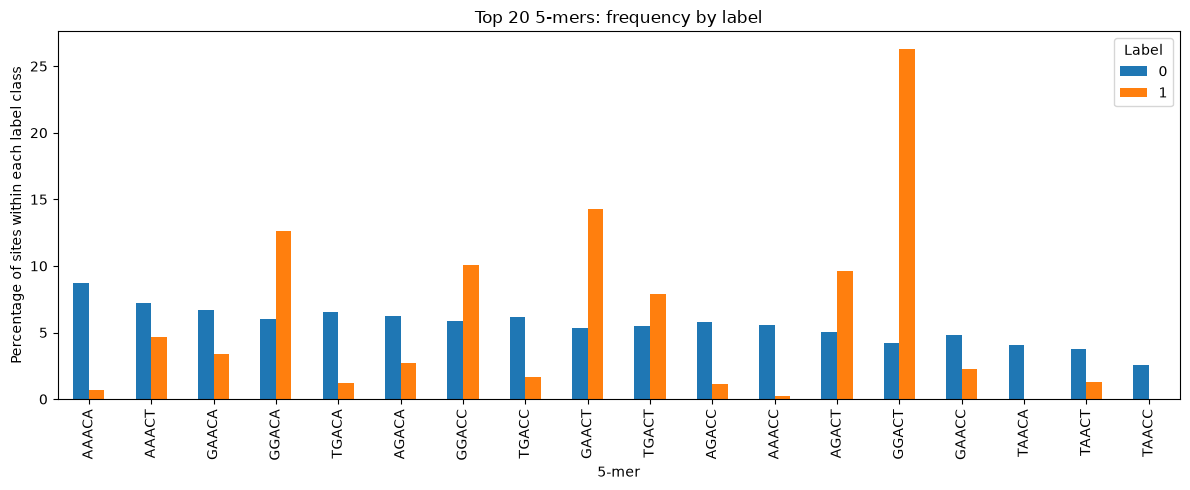

In [9]:
sequence_counts = pd.crosstab(
    labelled_sites["central_5mer"],
    labelled_sites["label"],
).reindex(columns=[0, 1], fill_value=0)

# Each column sums to 100% when that label class is present.
sequence_percentages = (
    sequence_counts
    .div(
        sequence_counts.sum(axis=0).replace(0, float("nan")),
        axis="columns",
    )
    * 100
)

top_sequences = (
    sequence_counts.sum(axis=1)
    .nlargest(20)
    .index
)

display(sequence_counts.loc[top_sequences])

sequence_percentages.loc[top_sequences].plot.bar(
    figsize=(12, 5),
)

plt.xlabel("5-mer")
plt.ylabel("Percentage of sites within each label class")
plt.title("Top 20 5-mers: frequency by label")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

## Sequence motifs
Interpret positive fractions alongside site counts: a motif represented by very few sites has a less reliable estimate.

label,unmodified_sites,modified_sites,total_sites,positive_fraction
central_5mer,,,,
AAACA,10114,38,10152,0.003743
AAACT,8372,255,8627,0.029558
GAACA,7747,187,7934,0.023569
GGACA,7036,691,7727,0.089427
TGACA,7650,68,7718,0.008811
AGACA,7249,147,7396,0.019876
GGACC,6801,552,7353,0.075071
TGACC,7214,90,7304,0.012322
GAACT,6174,783,6957,0.112549


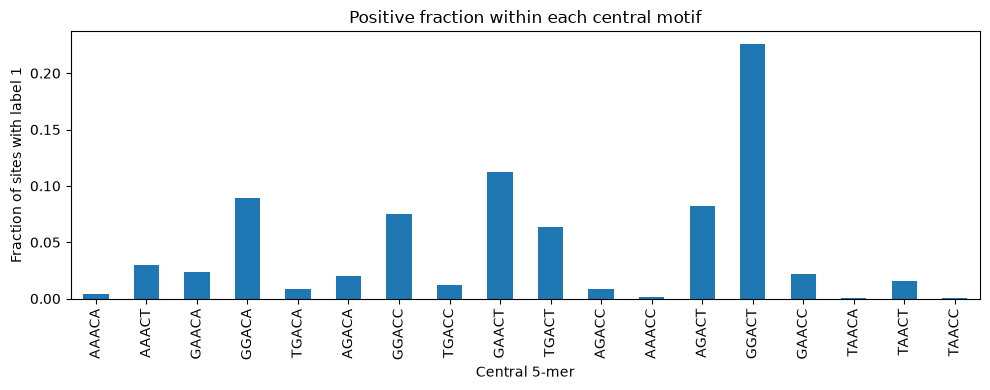

In [10]:
motif_counts = pd.crosstab(
    labelled_sites["central_5mer"],
    labelled_sites["label"],
).reindex(columns=[0, 1], fill_value=0)

motif_summary = motif_counts.rename(
    columns={0: "unmodified_sites", 1: "modified_sites"}
)

motif_summary["total_sites"] = motif_summary.sum(axis=1)

motif_summary["positive_fraction"] = (
    motif_summary["modified_sites"]
    / motif_summary["total_sites"]
)

motif_summary = motif_summary.sort_values(
    "total_sites", ascending=False
)

display(motif_summary)

motif_summary["positive_fraction"].plot.bar(
    figsize=(10, 4)
)

plt.xlabel("Central 5-mer")
plt.ylabel("Fraction of sites with label 1")
plt.title("Positive fraction within each central motif")
plt.tight_layout()
plt.show()

In [11]:
# Data-quality check to investigate unexpected motifs before deciding whether to exclude anything  
valid_motif = sites["central_5mer"].str.fullmatch(
    r"[AGT][AG]AC[ACT]",
    na=False,
)

print("Sites outside the expected DRACH motif:", (~valid_motif).sum())

display(
    sites.loc[
        ~valid_motif,
        SITE_KEYS + ["sequence", "central_5mer"]
    ].head()
)

Sites outside the expected DRACH motif: 0


,transcript_id,transcript_position,sequence,central_5mer


## Central signal features

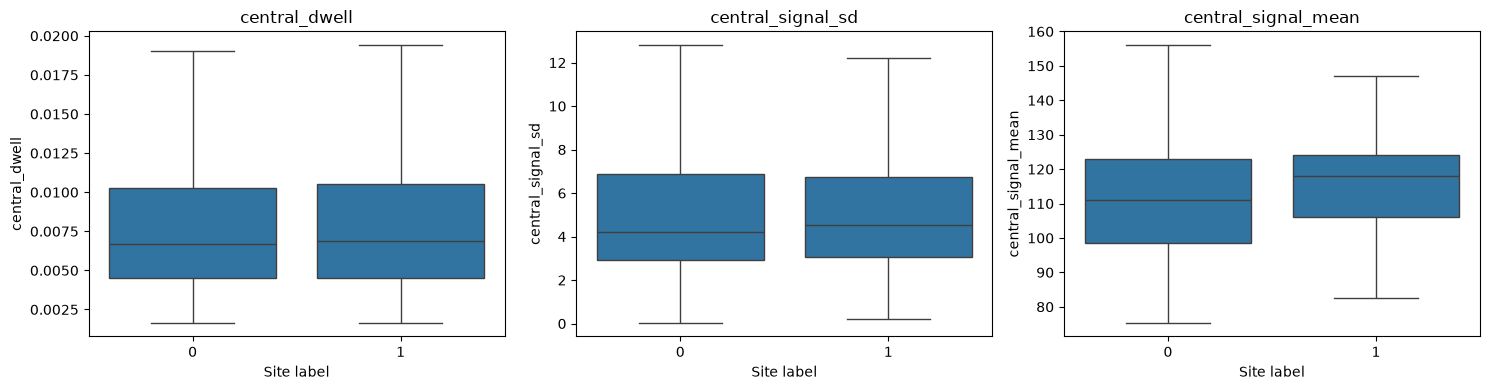

In [14]:
central_features = [
    "central_dwell",
    "central_signal_sd",
    "central_signal_mean",
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, central_features):
    sns.boxplot(
        data=labelled_reads,
        x="label",
        y=feature,
        order=[0, 1],
        showfliers=False,
        ax=ax,
    )
    ax.set_title(feature)
    ax.set_xlabel("Site label")

plt.tight_layout()
plt.show()

## Compare site averages

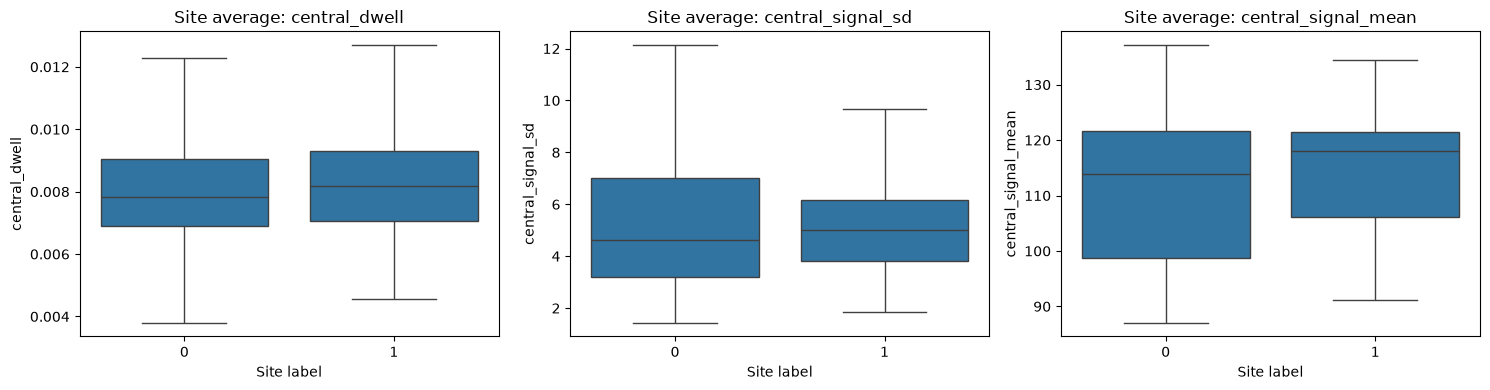

In [15]:
central_site_means = (
    labelled_reads
    .groupby(SITE_KEYS, as_index=False)[central_features]
    .mean()
    .merge(
        labelled_sites[SITE_KEYS + ["label"]],
        on=SITE_KEYS,
        validate="one_to_one",
    )
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, central_features):
    sns.boxplot(
        data=central_site_means,
        x="label",
        y=feature,
        order=[0, 1],
        showfliers=False,
        ax=ax,
    )

    ax.set_title(f"Site average: {feature}")
    ax.set_xlabel("Site label")

plt.tight_layout()
plt.show()